# Overtake Probability Model v5 — IP04 Implementation

**Data version:** `data/v5` (79 columns per row)  
**Battle definition:** adjacent attacker/defender pairs with actual gap `< 3.0s`  
**New over v4:** constructor/team features, richer driver form, race-situation context  
**Baseline:** v4 (IP03) — see comparison at bottom

### IP04 highlights implemented in v5
| Feature group | New columns |
|---|---|
| Team/constructor (§1.1) | `attacker_team`, `defender_team`, `same_team`, `attacker_team_pace_rank`, `defender_team_pace_rank`, `team_delta` |
| Driver form (§1.2) | `attacker_positions_gained_avg`, `defender_positions_gained_avg`, `attacker_quali_vs_teammate`, `defender_quali_vs_teammate`, `attacker_race_pace_vs_teammate`, `defender_race_pace_vs_teammate` |
| Race situation (§1.3) | `gap_to_car_ahead`, `gap_to_car_behind`, `drs_train_size`, `race_phase`, `stint_phase` |

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, f1_score,
    classification_report, confusion_matrix,
)

import xgboost as xgb
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

ROOT = Path("..").resolve()


## 1. Load v5 data — train (2022–2024) and test (2025)

In [2]:
TRAIN_YEARS = [2022, 2023, 2024]
TEST_YEARS  = [2025]
DATA_DIR = ROOT / "data" / "v5"

def load_years(years):
    frames = []
    for yr in years:
        p = DATA_DIR / f"battles_{yr}.csv"
        if not p.exists():
            print(f"WARNING: {p} not found — skipping {yr}")
            continue
        frame = pd.read_csv(p, encoding="utf-8")
        frames.append(frame)
        races = frame["race_name"].nunique() if "race_name" in frame.columns else 0
        print(f"  {yr}: {len(frame):,} battles across {races} races")
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

print("Training data (2022-2024):")
df_train_raw = load_years(TRAIN_YEARS)
print(f"  Total train rows : {len(df_train_raw):,}")
print(f"  Overtake rate    : {df_train_raw['overtake'].mean():.2%}")
print()
print("Test data (2025 holdout):")
df_test_raw = load_years(TEST_YEARS)
if not df_test_raw.empty:
    print(f"  Total test rows  : {len(df_test_raw):,}")
    print(f"  Overtake rate    : {df_test_raw['overtake'].mean():.2%}")
else:
    print("  No 2025 data available")

Training data (2022-2024):
  2022: 9,410 battles across 18 races
  2023: 9,090 battles across 15 races
  2024: 9,403 battles across 17 races
  Total train rows : 27,903
  Overtake rate    : 7.07%

Test data (2025 holdout):
  2025: 11,105 battles across 17 races
  Total test rows  : 11,105
  Overtake rate    : 6.04%


## 2. Data quality — filter pit-stop overtakes

In [3]:
pit_train = df_train_raw["pit_stop_involved"].sum()
pit_test  = df_test_raw["pit_stop_involved"].sum() if not df_test_raw.empty else 0
print(f"Pit-stop battles removed — train: {pit_train:,}, test: {pit_test:,}")

df_train = df_train_raw[~df_train_raw["pit_stop_involved"]].copy()
df_test  = df_test_raw[~df_test_raw["pit_stop_involved"]].copy() if not df_test_raw.empty else pd.DataFrame()
print(f"Remaining — train: {len(df_train):,}, test: {len(df_test):,}")

Pit-stop battles removed — train: 1,453, test: 499
Remaining — train: 26,450, test: 10,606


## 3. Feature engineering

In [4]:
def identify_battle_sequences(df):
    df = df.sort_values(["race_name", "attacker", "defender", "lap_number"]).copy()
    df["pair_id"] = df["attacker"] + "_vs_" + df["defender"]
    df["lap_gap"] = df.groupby(["race_name", "pair_id"])["lap_number"].diff().fillna(1)
    df["battle_break"] = (df["lap_gap"] > 1).astype(int)
    df["battle_seq"] = df.groupby(["race_name", "pair_id"])["battle_break"].cumsum()
    df["battle_group"] = df["race_name"] + "_" + df["pair_id"] + "_" + df["battle_seq"].astype(str)
    return df

def engineer_features(df):
    df = identify_battle_sequences(df)
    df["position_delta"] = df["attacker_position"] - df["defender_position"]
    df["compound_advantage"] = (
        df["attacker_tyre_compound"].map({"SOFT": 3, "MEDIUM": 2, "HARD": 1}).fillna(0)
        - df["defender_tyre_compound"].map({"SOFT": 3, "MEDIUM": 2, "HARD": 1}).fillna(0)
    )
    df["tyre_cliff_risk"] = (df["attacker_tyre_age"] >= 20).astype(int)
    df["qualification_rank_difference"] = (
        df["defender_qualification_rank"] - df["attacker_qualification_rank"]
    )
    g = df.groupby("battle_group")
    df["battle_duration"] = g["lap_number"].transform("count")
    df["closing_rate"] = g["gap_ahead"].transform(lambda s: s.diff().mean())
    df["closing_rate"] = df["closing_rate"].fillna(0)
    return df

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test) if not df_test.empty else pd.DataFrame()

print(f"After feature engineering — train columns: {len(df_train.columns)}")
print(f"New IP04 columns in data: {[c for c in df_train.columns if c in ['attacker_team','defender_team','same_team','gap_to_car_ahead','gap_to_car_behind','drs_train_size','race_phase','stint_phase','attacker_team_pace_rank','defender_team_pace_rank','team_delta','attacker_positions_gained_avg','defender_positions_gained_avg','attacker_quali_vs_teammate','defender_quali_vs_teammate','attacker_race_pace_vs_teammate','defender_race_pace_vs_teammate']]}")

After feature engineering — train columns: 93
New IP04 columns in data: ['attacker_team', 'defender_team', 'same_team', 'gap_to_car_ahead', 'gap_to_car_behind', 'drs_train_size', 'race_phase', 'stint_phase', 'attacker_team_pace_rank', 'defender_team_pace_rank', 'team_delta', 'attacker_positions_gained_avg', 'defender_positions_gained_avg', 'attacker_quali_vs_teammate', 'defender_quali_vs_teammate', 'attacker_race_pace_vs_teammate', 'defender_race_pace_vs_teammate']


## 4. Prepare train/test matrices

In [5]:
DROP_COLS = [
    "attacker", "defender", "overtake", "track",
    "attacker_qualification_rank", "defender_qualification_rank",
    "pit_stop_involved",
    "event_date",
    "overtake_within_2",
    "overtake_within_3",
    "pair_id", "lap_gap", "battle_break", "battle_seq", "battle_group",
]

FEATURE_COLS = [c for c in df_train.columns if c not in DROP_COLS]
TARGET = "overtake"

X = df_train[FEATURE_COLS].copy()
y = df_train[TARGET].astype(int).values
groups = df_train["race_name"].values

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"Features: {len(FEATURE_COLS)}")
print(f"  Numeric    : {len(num_cols)}")
print(f"  Categorical: {len(cat_cols)}")
print(f"  Positive rate: {y.mean():.2%}")
print(f"\nCategorical: {cat_cols}")
print(f"Numeric (first 20): {num_cols[:20]}")
print(f"Numeric (rest):     {num_cols[20:]}")

if not df_test.empty:
    X_test = df_test[FEATURE_COLS].copy()
    y_test = df_test[TARGET].astype(int).values
else:
    X_test = y_test = None

Features: 78
  Numeric    : 61
  Categorical: 17
  Positive rate: 5.36%

Categorical: ['race_name', 'safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'attacker_fresh_tyre', 'defender_fresh_tyre', 'sector_type', 'is_in_drs_zone', 'track_type', 'rainfall', 'compound_mismatch', 'attacker_team', 'defender_team', 'same_team', 'race_phase', 'stint_phase']
Numeric (first 20): ['year', 'round_number', 'lap_number', 'total_laps', 'race_progress', 'attacker_position', 'defender_position', 'attacker_lap_time', 'defender_lap_time', 'gap_ahead', 'pace_delta', 'attacker_speed_i1', 'defender_speed_i1', 'attacker_speed_i2', 'defender_speed_i2', 'attacker_finish_line_speed', 'defender_finish_line_speed', 'attacker_straight_speed', 'defender_straight_speed', 'speed_i1_delta']
Numeric (rest):     ['speed_i2_delta', 'speed_fl_delta', 'speed_st_delta', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'attacker_stint', 'defender_stint', 'sector', 'drs_zone_leng

## 5. Preprocessing

In [6]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
print(f"Preprocessor: {len(num_cols)} numeric, {len(cat_cols)} categorical columns")

Preprocessor: 61 numeric, 17 categorical columns


## 6. Train the compact v5 baseline

Use the current published v5 training configuration, then keep the notebook focused on core cross-validated and 2025 holdout evaluation.

In [7]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

X_transformed = preprocessor.fit_transform(X)
scale_pos_weight = (y == 0).sum() / max((y == 1).sum(), 1)
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

best_params = {
    "n_estimators": 800,
    "max_depth": 3,
    "learning_rate": 0.014090050353199953,
    "min_child_weight": 10,
    "subsample": 0.8019481543952183,
    "colsample_bytree": 0.8259348980687131,
    "reg_alpha": 0.009535726031875313,
    "reg_lambda": 0.006312092511687785,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "aucpr",
    "random_state": 42,
    "n_jobs": -1,
}

print("Using the current v5 3.0s-battle training configuration for a compact rerun.")
print(best_params)


scale_pos_weight = 17.6
Using the current v5 3.0s-battle training configuration for a compact rerun.
{'n_estimators': 800, 'max_depth': 3, 'learning_rate': 0.014090050353199953, 'min_child_weight': 10, 'subsample': 0.8019481543952183, 'colsample_bytree': 0.8259348980687131, 'reg_alpha': 0.009535726031875313, 'reg_lambda': 0.006312092511687785, 'scale_pos_weight': np.float64(17.639887244538407), 'eval_metric': 'aucpr', 'random_state': 42, 'n_jobs': -1}


## 7. Evaluate best XGBoost via GroupKFold CV

In [8]:
best_xgb = xgb.XGBClassifier(**best_params)
probas_cv = cross_val_predict(
    best_xgb, X_transformed, y,
    cv=gkf, groups=groups,
    method="predict_proba", n_jobs=1,
)[:, 1]

roc_auc = roc_auc_score(y, probas_cv)
pr_auc  = average_precision_score(y, probas_cv)
brier   = brier_score_loss(y, probas_cv)

print(f"XGBoost CV Results (2022-2024):")
print(f"  ROC-AUC : {roc_auc:.4f}")
print(f"  PR-AUC  : {pr_auc:.4f}")
print(f"  Brier   : {brier:.4f}")
print(f"\nMean predicted proba (overtake=1): {probas_cv[y == 1].mean():.4f}")
print(f"Mean predicted proba (overtake=0): {probas_cv[y == 0].mean():.4f}")
print(f"Separation: {probas_cv[y == 1].mean() - probas_cv[y == 0].mean():.4f}")
print("\nInterpretation:")
print("- These cross-validated metrics summarize how the wider 3.0s v5 battle definition behaves on 2022-2024 data.")
print("- PR-AUC matters most for this notebook because positive overtakes are still rare even after widening the candidate set.")
print("- The probability separation check tells us whether the model is producing a useful score spread rather than clustering everything near the base rate.")


XGBoost CV Results (2022-2024):
  ROC-AUC : 0.9534
  PR-AUC  : 0.6961
  Brier   : 0.0602

Mean predicted proba (overtake=1): 0.7740
Mean predicted proba (overtake=0): 0.1289
Separation: 0.6451

Interpretation:
- These cross-validated metrics summarize how the wider 3.0s v5 battle definition behaves on 2022-2024 data.
- PR-AUC matters most for this notebook because positive overtakes are still rare even after widening the candidate set.
- The probability separation check tells us whether the model is producing a useful score spread rather than clustering everything near the base rate.


## 8. ROC & PR curves

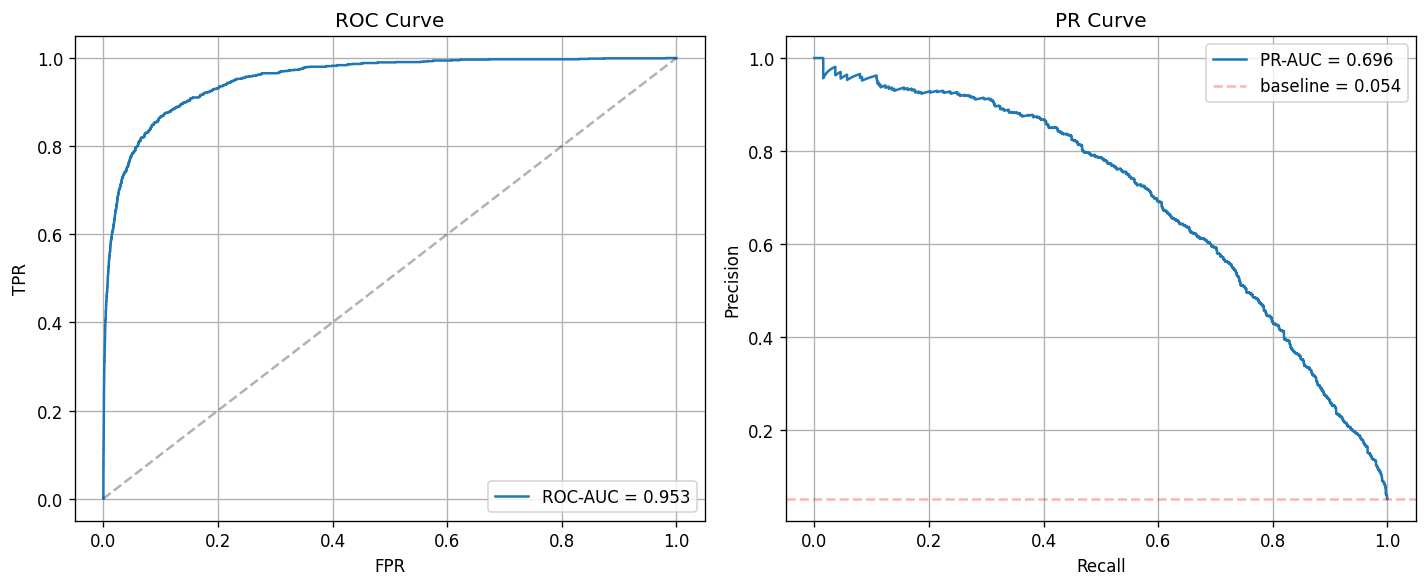

Interpretation:
- The ROC curve shows strong global ranking quality, but the PR curve is the better operational view for overtake alerts.
- Staying clearly above the class baseline means the model is finding informative positive cases instead of just mirroring the low positive rate.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y, probas_cv)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set(xlabel="FPR", ylabel="TPR", title="ROC Curve")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y, probas_cv)
axes[1].plot(rec, prec, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].axhline(y.mean(), color="r", linestyle="--", alpha=0.3, label=f"baseline = {y.mean():.3f}")
axes[1].set(xlabel="Recall", ylabel="Precision", title="PR Curve")
axes[1].legend()

plt.tight_layout()
plt.show()
print("Interpretation:")
print("- The ROC curve shows strong global ranking quality, but the PR curve is the better operational view for overtake alerts.")
print("- Staying clearly above the class baseline means the model is finding informative positive cases instead of just mirroring the low positive rate.")


## 9. Calibration & multi-threshold evaluation

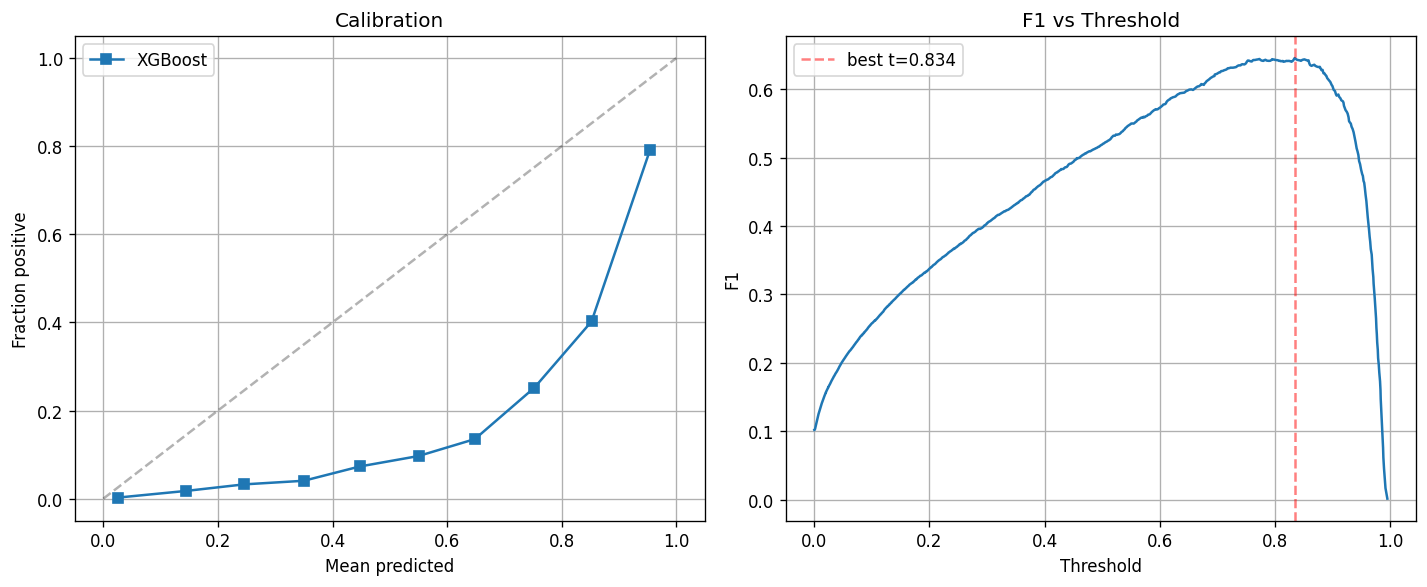

Best F1 threshold: 0.834  (F1 = 0.6456)
Interpretation:
- The calibration plot tells us whether the predicted probabilities can be read literally or need threshold-aware interpretation.
- The threshold sweep picks the operating point used later in holdout evaluation and artifact metadata.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fraction_pos, mean_pred = calibration_curve(y, probas_cv, n_bins=10)
axes[0].plot(mean_pred, fraction_pos, "s-", label="XGBoost")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set(xlabel="Mean predicted", ylabel="Fraction positive", title="Calibration")
axes[0].legend()

thresholds = np.unique(np.round(probas_cv, 6))
if len(thresholds) > 2000:
    idx = np.linspace(0, len(thresholds) - 1, 2000).astype(int)
    thresholds = thresholds[idx]
f1_scores = []
for t in thresholds:
    preds = (probas_cv >= t).astype(int)
    f1_scores.append(f1_score(y, preds, zero_division=0))
best_idx = int(np.argmax(f1_scores))
best_t = float(thresholds[best_idx])
axes[1].plot(thresholds, f1_scores)
axes[1].axvline(best_t, color="r", linestyle="--", alpha=0.5, label=f"best t={best_t:.3f}")
axes[1].set(xlabel="Threshold", ylabel="F1", title="F1 vs Threshold")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Best F1 threshold: {best_t:.3f}  (F1 = {f1_scores[best_idx]:.4f})")
print("Interpretation:")
print("- The calibration plot tells us whether the predicted probabilities can be read literally or need threshold-aware interpretation.")
print("- The threshold sweep picks the operating point used later in holdout evaluation and artifact metadata.")


## 10. Confusion matrix

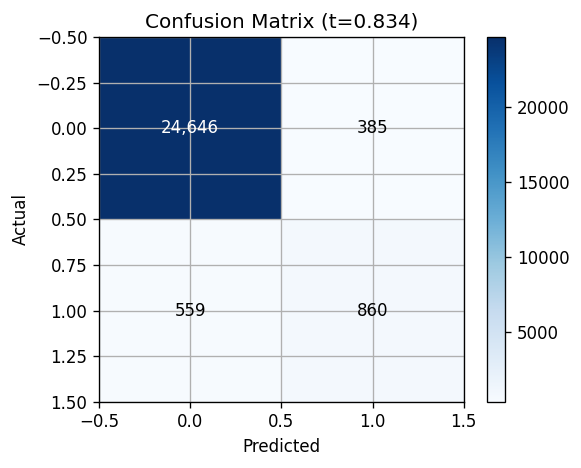

              precision    recall  f1-score   support

 no overtake       0.98      0.98      0.98     25031
    overtake       0.69      0.61      0.65      1419

    accuracy                           0.96     26450
   macro avg       0.83      0.80      0.81     26450
weighted avg       0.96      0.96      0.96     26450

Interpretation:
- This confusion matrix shows the practical tradeoff once the probability score is converted into a binary next-lap prediction.
- For v5, false negatives are missed overtakes, while false positives are scenarios the app would flag too aggressively.


In [11]:
best_preds = (probas_cv >= best_t).astype(int)
cm = confusion_matrix(y, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set(xlabel="Predicted", ylabel="Actual", title=f"Confusion Matrix (t={best_t:.3f})")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(y, best_preds, target_names=["no overtake", "overtake"]))
print("Interpretation:")
print("- This confusion matrix shows the practical tradeoff once the probability score is converted into a binary next-lap prediction.")
print("- For v5, false negatives are missed overtakes, while false positives are scenarios the app would flag too aggressively.")


## 11. Feature importance

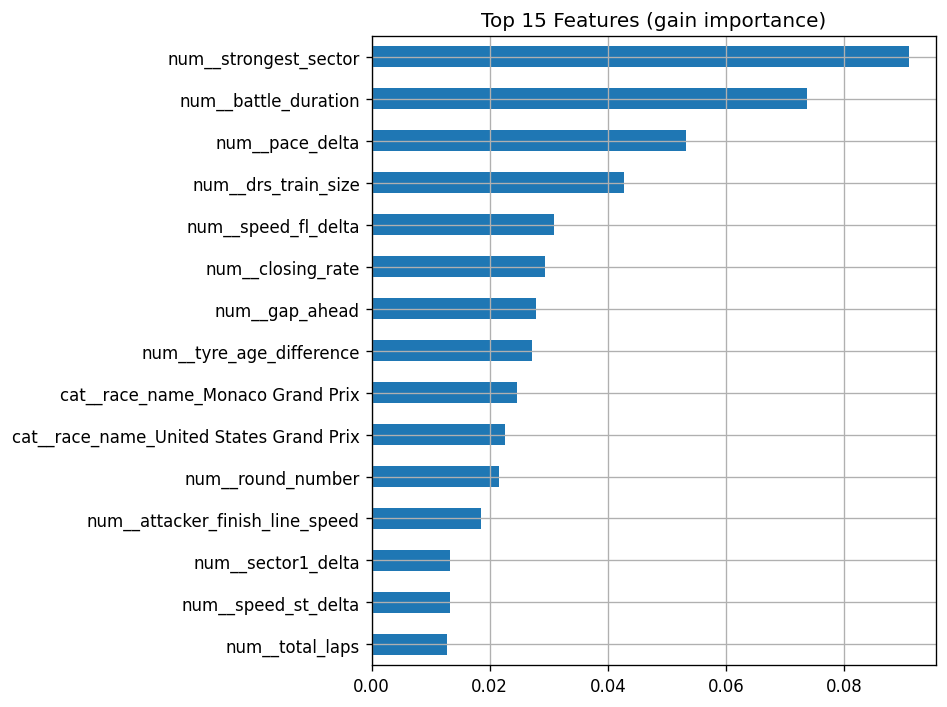

num__strongest_sector                      0.091022
num__battle_duration                       0.073695
num__pace_delta                            0.053255
num__drs_train_size                        0.042677
num__speed_fl_delta                        0.030882
num__closing_rate                          0.029329
num__gap_ahead                             0.027904
num__tyre_age_difference                   0.027148
cat__race_name_Monaco Grand Prix           0.024607
cat__race_name_United States Grand Prix    0.022555
num__round_number                          0.021549
num__attacker_finish_line_speed            0.018514
num__sector1_delta                         0.013359
num__speed_st_delta                        0.013282
num__total_laps                            0.012722

Interpretation:
- The top-gain features show which race, tyre, and pace signals are driving next-lap overtake probability in the widened v5 setup.
- This helps confirm whether the 3.0s battle definition is still produci

In [12]:
fi_clf = xgb.XGBClassifier(**best_params)
fi_clf.fit(X_transformed, y)

t_names_all = preprocessor.get_feature_names_out()
fi = pd.Series(fi_clf.feature_importances_, index=t_names_all).sort_values(ascending=True)

top_fi = fi.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_fi.plot.barh(ax=ax)
ax.set_title("Top 15 Features (gain importance)")
plt.tight_layout()
plt.show()

print(top_fi.sort_values(ascending=False).to_string())
print("\nInterpretation:")
print("- The top-gain features show which race, tyre, and pace signals are driving next-lap overtake probability in the widened v5 setup.")
print("- This helps confirm whether the 3.0s battle definition is still producing a model driven by plausible race dynamics.")


## 12. Save model artefacts

In [13]:
import joblib
import json as _json
import datetime

ARTIFACTS_DIR = ROOT / "models" / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

final_xgb = xgb.XGBClassifier(**best_params)
final_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
X_all = final_preprocessor.fit_transform(X)
final_cal = CalibratedClassifierCV(final_xgb, method="isotonic", cv=5)
final_cal.fit(X_all, y)

full_pipeline = Pipeline([
    ("preprocess", final_preprocessor),
    ("classifier", final_cal),
])

model_path = ARTIFACTS_DIR / "overtake_model_v5.pkl"
meta_path  = ARTIFACTS_DIR / "overtake_model_v5_meta.json"

joblib.dump(full_pipeline, model_path)

meta = {
    "model": "XGBoost",
    "calibration": "isotonic",
    "features": FEATURE_COLS,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "best_params": {k: v for k, v in best_params.items() if k != "n_jobs"},
    "threshold": float(best_t),
    "train_years": TRAIN_YEARS,
    "test_years": TEST_YEARS,
    "train_rows": int(len(X)),
    "test_rows": int(len(X_test)) if X_test is not None else 0,
    "overtake_rate": float(y.mean()),
    "cv_metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "brier": float(brier),
    },
    "data_version": "v5",
    "battle_gap_threshold_seconds": 3.0,
    "ip04_improvements": [
        "team_constructor_features",
        "team_pace_ranking",
        "same_team_battle_flag",
        "gap_to_surrounding_cars",
        "drs_train_detection",
        "race_phase_buckets",
        "stint_phase_buckets",
        "positions_gained_rolling",
        "quali_vs_teammate",
        "race_pace_vs_teammate",
        "regularization_tuning",
    ],
    "baseline_model": "v4 IP03 (model_testing_4, data v4)",
    "saved_at": datetime.datetime.now().isoformat(),
}
meta_path.write_text(_json.dumps(meta, indent=2))

print(f"Model saved    -> {model_path}")
print(f"Metadata saved -> {meta_path}")
print(f"Trained on     : {TRAIN_YEARS}  ({len(X):,} battles)")
print(f"Decision threshold: {best_t:.3f}")


Model saved    -> /Users/aminnami/Desktop/hamid/ai_in_industry/formula1-overtake-prediction/models/artifacts/overtake_model_v5.pkl
Metadata saved -> /Users/aminnami/Desktop/hamid/ai_in_industry/formula1-overtake-prediction/models/artifacts/overtake_model_v5_meta.json
Trained on     : [2022, 2023, 2024]  (26,450 battles)
Decision threshold: 0.834


## 13. Holdout evaluation on 2025 data

2025 Holdout Results:
  ROC-AUC : 0.9673
  PR-AUC  : 0.7521
  Brier   : 0.0192
  n       : 10,606


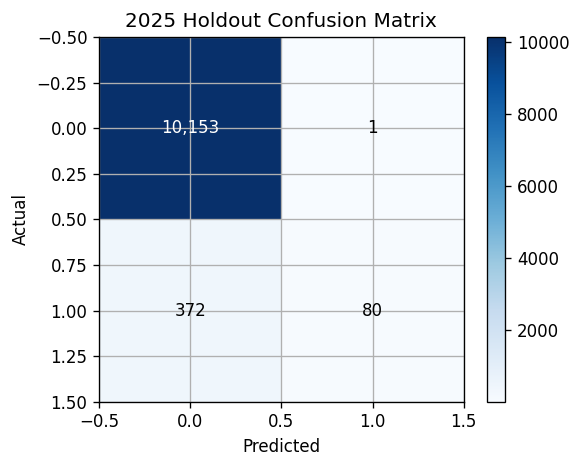


              precision    recall  f1-score   support

 no overtake       0.96      1.00      0.98     10154
    overtake       0.99      0.18      0.30       452

    accuracy                           0.96     10606
   macro avg       0.98      0.59      0.64     10606
weighted avg       0.97      0.96      0.95     10606

               race_name  rows  actual_positive_rate  predicted_positive_rate  mean_probability
    Abu Dhabi Grand Prix   677              0.079764                 0.016248          0.086736
  Mexico City Grand Prix   581              0.061962                 0.018933          0.055299
Saudi Arabian Grand Prix   452              0.061947                 0.017699          0.062629
      Spanish Grand Prix   514              0.054475                 0.009728          0.059484
     Canadian Grand Prix   724              0.053867                 0.005525          0.054740
      Bahrain Grand Prix   687              0.053857                 0.016012          0.060801


In [14]:
if X_test is not None and y_test is not None:
    probas_2025 = full_pipeline.predict_proba(X_test)[:, 1]
    roc_2025 = roc_auc_score(y_test, probas_2025)
    pr_2025  = average_precision_score(y_test, probas_2025)
    brier_2025 = brier_score_loss(y_test, probas_2025)

    print(f"2025 Holdout Results:")
    print(f"  ROC-AUC : {roc_2025:.4f}")
    print(f"  PR-AUC  : {pr_2025:.4f}")
    print(f"  Brier   : {brier_2025:.4f}")
    print(f"  n       : {len(y_test):,}")

    preds_2025 = (probas_2025 >= best_t).astype(int)
    cm_2025 = confusion_matrix(y_test, preds_2025)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm_2025, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm_2025[i, j]:,}", ha="center", va="center",
                    color="white" if cm_2025[i, j] > cm_2025.max() / 2 else "black")
    ax.set(xlabel="Predicted", ylabel="Actual", title="2025 Holdout Confusion Matrix")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    meta = _json.loads(meta_path.read_text())
    meta["holdout_metrics"] = {
        "roc_auc": float(roc_2025),
        "pr_auc": float(pr_2025),
        "brier": float(brier_2025),
        "best_f1_threshold": float(best_t),
        "confusion_matrix": cm_2025.tolist(),
    }
    meta_path.write_text(_json.dumps(meta, indent=2))

    print(f"\n{classification_report(y_test, preds_2025, target_names=['no overtake', 'overtake'])}")
    race_summary = (
        pd.DataFrame({"race_name": df_test["race_name"].values, "actual": y_test, "proba": probas_2025, "pred": preds_2025})
        .groupby("race_name", as_index=False)
        .agg(rows=("actual", "size"), actual_positive_rate=("actual", "mean"), predicted_positive_rate=("pred", "mean"), mean_probability=("proba", "mean"))
        .sort_values("actual_positive_rate", ascending=False)
    )
    print(race_summary.head(10).to_string(index=False))
    print("\nInterpretation:")
    print("- This 2025 holdout tests whether the widened 3.0s battle definition still generalizes to a new season.")
    print("- Comparing actual and predicted race-level positive rates helps reveal whether the model is over-alerting or under-alerting on specific circuits.")
else:
    roc_2025 = pr_2025 = brier_2025 = None
    print("No 2025 holdout data")
